### Laboration 3. Linjär klassificering.

Syftet med denna rapport är att undersöka huruvida förhållandet mellan X- och Y-variablerna påverkas beroende på olika värden på **k** och **m**. 
Först klassificeras datan med hjälp av funktionen som räknar ut om en punkt ligger till höger om/ovanför eller vänster om/nedanför linjen. En rak linje bestäms utifrån följande ekvationer: <br>
t(x) = -1x + 0<br>
f(x) = -0.489x<br>
g(x) = -2x + 0.16<br>
h(x) = 800x - 120

In [12]:
import pandas as pd
import matplotlib.pyplot as plt


def open_data():
    data = pd.read_csv("unlabelled_data.csv", header=None)
    return data

def add_label(k, m, data=open_data()):
    data_values = data.values
    label_list = []

    for x, y in data_values:
        if y > (k*x + m):
            l = 1
            label_list.append(l)
        else:
            l = 0
            label_list.append(l)
    return label_list

def classify_points(k,m):
    data = open_data()
    data['label'] = add_label(k, m)
    print(f"The quantity of points classified as 0: {len(data.loc[data['label']==0])}",
          f"\nThe quantity of points classified as 1: {len(data.loc[data['label'] == 1])}")
    return data

 

Datan visualiseras tillsammans med ovanstående linjer. Då skillnaden i antalet klassificerade punkter är inte markant och själva datan saknar kontexten, kan man konkludera att det inte finns någon anledning att föredra en viss linje. Rent logiskt och visuellt känns det dock att linjen som bestämms av ekvationen **h(x) = 800x - 120** är minst passande. 

The quantity of points classified as 0: 298 
The quantity of points classified as 1: 302
The quantity of points classified as 0: 299 
The quantity of points classified as 1: 301
The quantity of points classified as 0: 299 
The quantity of points classified as 1: 301
The quantity of points classified as 0: 298 
The quantity of points classified as 1: 302


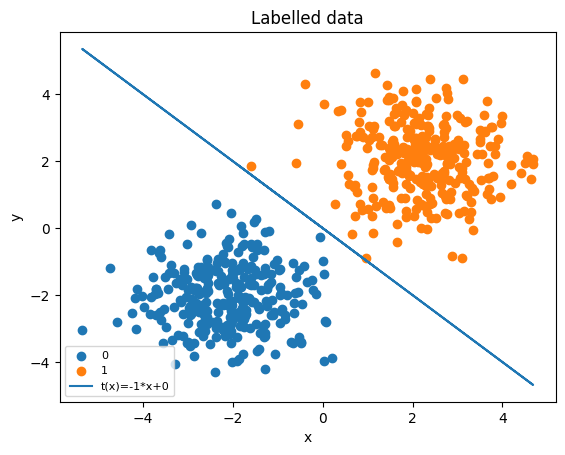

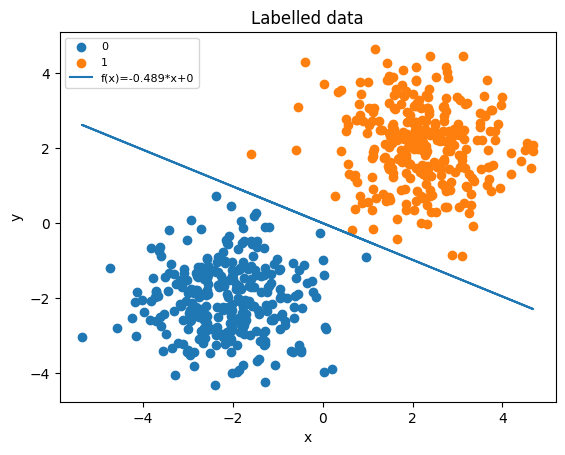

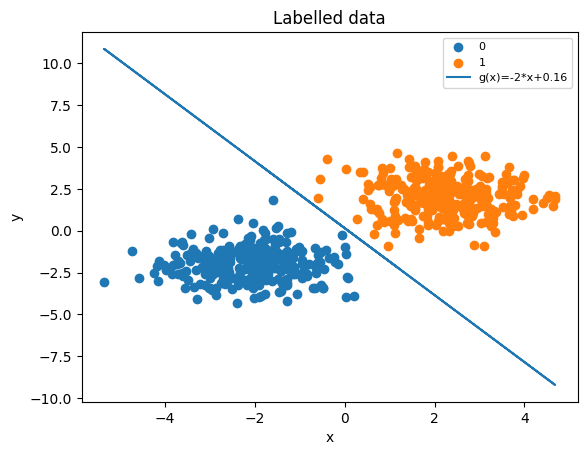

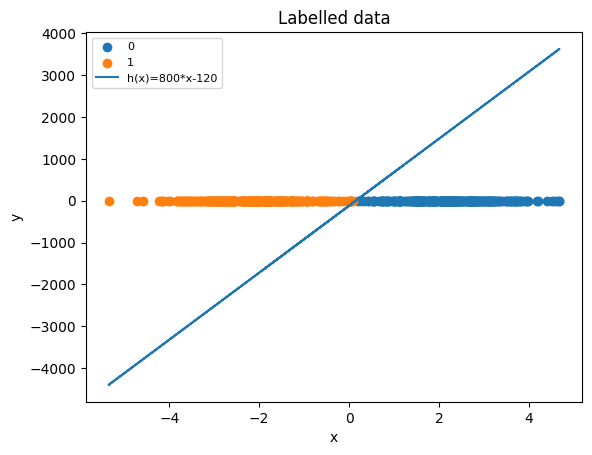

In [13]:
def plot_functions(k,m,plot_label):
    df = classify_points(k,m)
    x = df.iloc[:,0]
    f = lambda x: k*x + m
    df_0 = df.loc[df['label'] == 0]
    df_1 = df.loc[df['label'] == 1]

    fig, ax = plt.subplots()
    ax.scatter(df_0[0], df_0[1], label='0')
    ax.scatter(df_1[0], df_1[1], label='1')
    ax.plot(x, f(x), '-',label=plot_label)
    ax.set(title='Labelled data',xlabel='x',ylabel='y')
    ax.legend(fontsize=8, loc='best')

def main():    
    plot_functions(-1,0, 't(x)=-1*x+0')
    plot_functions(-0.489,0,'f(x)=-0.489*x+0')
    plot_functions(-2,0.16, 'g(x)=-2*x+0.16')
    plot_functions(800,-120,'h(x)=800*x-120')

if __name__ == "__main__":
    main()